<a href="https://colab.research.google.com/github/Balamurugan-T326/DEEP-LEARNING/blob/main/EXPERIMENT-2/PART-C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Training with SGD
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8036 - loss: 0.7229 - val_accuracy: 0.9013 - val_loss: 0.3483
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9044 - loss: 0.3311 - val_accuracy: 0.9199 - val_loss: 0.2773
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9205 - loss: 0.2752 - val_accuracy: 0.9317 - val_loss: 0.2441
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9318 - loss: 0.2401 - val_accuracy: 0.9412 - val_loss: 0.2161
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9394 - loss: 0.2131 - val_accuracy: 0.9454 - val_loss: 0.1963
SGD
Test Loss : 0.1987
Test Accuracy : 0.9405

Training with Momentum
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9073 - loss: 0.3120 - val_accuracy: 0.9532 - val_loss: 0.1531
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9597 - loss: 0.1328 - val_accuracy: 0.9667 - val_loss: 0.1137
Epoch 3/

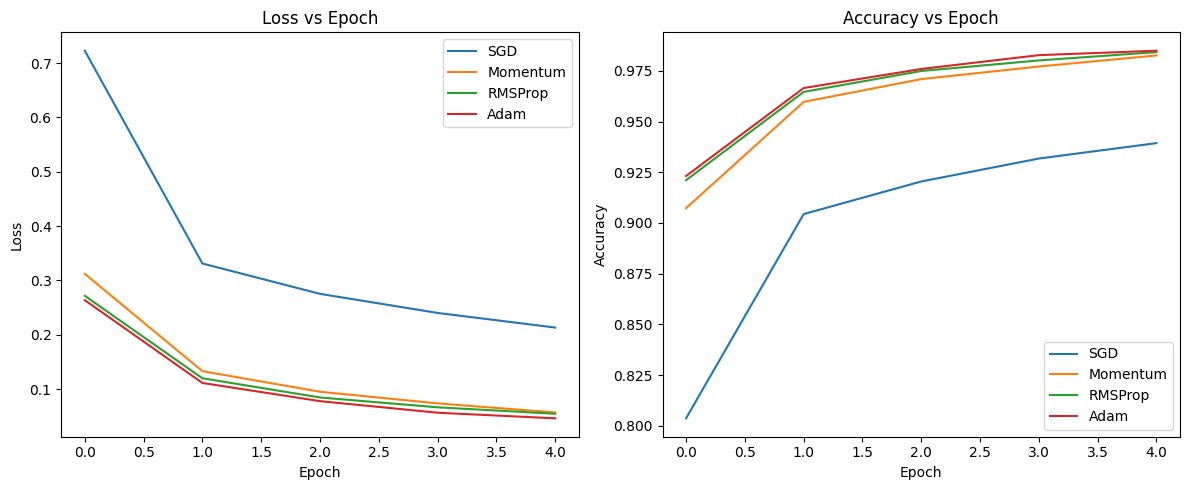

In [4]:
# Roll No: 24BAD016

import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize data
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

# Optimizers
optimizers = {
    "SGD": tf.keras.optimizers.SGD(),
    "Momentum": tf.keras.optimizers.SGD(momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(),
    "Adam": tf.keras.optimizers.Adam()
}

# Store histories
histories = {}

# Train models
for name, optimizer in optimizers.items():

    print("\nTraining with", name)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    histories[name] = history

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"{name}")
    print("Test Loss :", round(loss, 4))
    print("Test Accuracy :", round(accuracy, 4))

# ---------------- Loss Graph ----------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

for name in histories:
    plt.plot(histories[name].history["loss"], label=name)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# ---------------- Accuracy Graph ----------------

plt.subplot(1, 2, 2)

for name in histories:
    plt.plot(histories[name].history["accuracy"], label=name)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()